# exp_001 — Context measurement

This notebook is executable against the strongest available evidence. If a measured `main` manifest exists it is used; otherwise an unqualified run automatically displays the committed fixture smoke as a **harness-only** result. Set `EXP001_PHASE=main` to require a real model run and fail closed when it is absent.

The smoke result validates context construction, evidence offsets, storage, and processing. It is not a Qwen capability result. Repeated greedy prompts are not independent accuracy observations; independent task IDs are the capability denominator. The real-model path is Transformers, so do not compare its absolute values directly with llama.cpp/GGUF runs; use a matched Q8_0 llama.cpp condition for an operational cross-experiment reference.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'src').is_dir() and (candidate / 'experiments').is_dir())
EXPERIMENT_ROOT = ROOT / 'experiments/exp_001-context_measurement'
RESULTS_DIR = Path(os.environ.get('EXP001_RESULTS_DIR', EXPERIMENT_ROOT / 'results'))
REQUESTED_PHASE = os.environ.get('EXP001_PHASE', 'main')
PHASE = REQUESTED_PHASE
if 'EXP001_PHASE' not in os.environ and not (RESULTS_DIR / 'manifests' / 'main.json').is_file() and (RESULTS_DIR / 'manifests' / 'smoke.json').is_file():
    PHASE = 'smoke'
ALLOW_FIXTURE = os.environ.get('EXP001_ALLOW_FIXTURE', '1' if PHASE == 'smoke' else '0') == '1'
if ALLOW_FIXTURE and PHASE != 'smoke':
    raise ValueError('EXP001_ALLOW_FIXTURE=1 is permitted only for PHASE=smoke')
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(EXPERIMENT_ROOT))
from analyze import regenerate
from llm_lab.analysis import effective_context_by_task, effective_context_by_task_and_position, position_curve_rows, position_gap_rows

MANIFEST_PATH = RESULTS_DIR / 'manifests' / f'{PHASE}.json'
FIGURES_DIR = RESULTS_DIR / 'figures'
analysis_ready = MANIFEST_PATH.is_file()
if not analysis_ready:
    raise FileNotFoundError(f'required {PHASE} manifest is missing: {MANIFEST_PATH}')
regeneration = regenerate(MANIFEST_PATH, allow_fixture=ALLOW_FIXTURE)
manifest = __import__('json').loads(MANIFEST_PATH.read_text(encoding='utf-8'))
summary_rows = regeneration['summary_rows']
expected_scorer='calibrated.v1'
if any(row.get('scorer_version') not in (None, expected_scorer) for row in summary_rows):
    raise ValueError('summary contains a scorer version outside calibrated.v1')
available_summary_rows = [row for row in summary_rows if row.get('analysis_status', 'available') == 'available']
planned_lengths = tuple(manifest['context_lengths'])
planned_positions = tuple(manifest['evidence_positions'])
planned_tasks = tuple(manifest['task_types'])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print({'phase': PHASE, 'backend': manifest['backend'], 'evidence_status': 'harness-only' if manifest['backend'] == 'fixture' else 'measured-model', 'raw_sha256': regeneration['raw_results_sha256'], 'trial_n': regeneration['trial_n'], 'summary_rows': len(summary_rows), 'excluded_cells': regeneration['excluded_cell_n'], 'baseline_limited': regeneration['baseline_limited_task_types']})

{'phase': 'smoke', 'backend': 'fixture', 'evidence_status': 'harness-only', 'raw_sha256': 'a77d222ee1700a9d298bfc76b011a45b4a76753cded7a3886772bfbc7164a199', 'trial_n': 180, 'summary_rows': 18, 'excluded_cells': 0, 'baseline_limited': []}


In [2]:
if analysis_ready:
    coverage = pd.DataFrame([{key: row[key] for key in ('task_type', 'target_context_tokens', 'requested_evidence_position', 'attempted_n', 'completed_n', 'error_n', 'scored_n', 'scored_accuracy', 'analysis_status')} for row in position_curve_rows(summary_rows)])
    display(coverage)
    if manifest['backend'] == 'fixture':
        print('Interpretation boundary: fixture smoke checks the harness only; it is not Qwen evidence.')

,task_type,target_context_tokens,requested_evidence_position,attempted_n,completed_n,error_n,scored_n,scored_accuracy,analysis_status
0,literal_retrieval,8192,0.05,10,10,0,10,1.0,available
1,literal_retrieval,8192,0.50,10,10,0,10,1.0,available
2,literal_retrieval,8192,0.95,10,10,0,10,1.0,available
3,literal_retrieval,32768,0.05,10,10,0,10,1.0,available
4,literal_retrieval,32768,0.50,10,10,0,10,1.0,available
5,literal_retrieval,32768,0.95,10,10,0,10,1.0,available
6,multi_hop,8192,0.05,10,10,0,10,1.0,available
7,multi_hop,8192,0.50,10,10,0,10,1.0,available
8,multi_hop,8192,0.95,10,10,0,10,1.0,available
9,multi_hop,32768,0.05,10,10,0,10,1.0,available


Interpretation boundary: fixture smoke checks the harness only; it is not Qwen evidence.


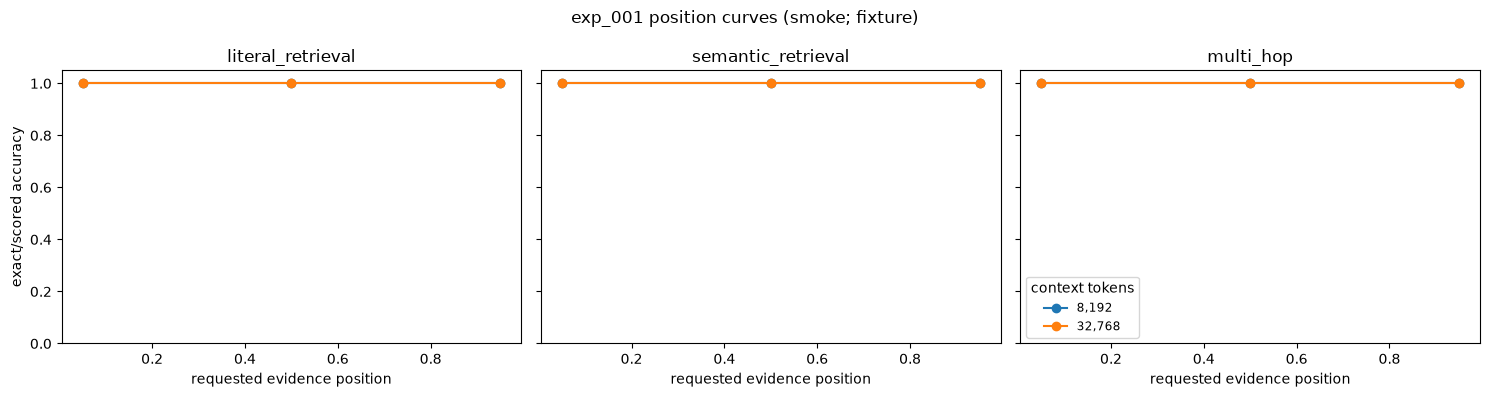

In [3]:
if analysis_ready:
    fig, axes = plt.subplots(1, len(planned_tasks), figsize=(15, 4), sharey=True)
    axes = [axes] if len(planned_tasks) == 1 else axes
    for axis, task_type in zip(axes, planned_tasks):
        for context_tokens in planned_lengths:
            points = sorted((row for row in available_summary_rows if row['task_type'] == task_type and row['target_context_tokens'] == context_tokens), key=lambda row: row['requested_evidence_position'])
            axis.plot([row['requested_evidence_position'] for row in points], [row['scored_accuracy'] for row in points], marker='o', label=f'{context_tokens:,}')
        axis.set_title(task_type)
        axis.set_xlabel('requested evidence position')
        axis.set_ylim(0, 1.05)
    axes[0].set_ylabel('exact/scored accuracy')
    axes[-1].legend(title='context tokens', fontsize='small')
    fig.suptitle(f'exp_001 position curves ({PHASE}; {manifest["backend"]})')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'position-curves.png', dpi=160)
    plt.show()

,task_type,target_context_tokens,edge_positions,middle_position,edge_accuracy,middle_accuracy,position_gap,edge_scored_n,middle_scored_n,status
0,literal_retrieval,8192,"[0.05, 0.95]",0.5,1.0,1.0,0.0,20,10,valid
1,literal_retrieval,32768,"[0.05, 0.95]",0.5,1.0,1.0,0.0,20,10,valid
2,multi_hop,8192,"[0.05, 0.95]",0.5,1.0,1.0,0.0,20,10,valid
3,multi_hop,32768,"[0.05, 0.95]",0.5,1.0,1.0,0.0,20,10,valid
4,semantic_retrieval,8192,"[0.05, 0.95]",0.5,1.0,1.0,0.0,20,10,valid
5,semantic_retrieval,32768,"[0.05, 0.95]",0.5,1.0,1.0,0.0,20,10,valid


,task_type,baseline_accuracy,status,crossing_context_tokens,effective_context_tokens,largest_tested_context_tokens
0,literal_retrieval,1.0,right_censored,None,None,32768
1,multi_hop,1.0,right_censored,None,None,32768
2,semantic_retrieval,1.0,right_censored,None,None,32768


,task_type,evidence_position,baseline_accuracy,status,crossing_context_tokens,effective_context_tokens
0,literal_retrieval,0.05,1.0,right_censored,None,None
1,literal_retrieval,0.50,1.0,right_censored,None,None
2,literal_retrieval,0.95,1.0,right_censored,None,None
3,multi_hop,0.05,1.0,right_censored,None,None
4,multi_hop,0.50,1.0,right_censored,None,None
5,multi_hop,0.95,1.0,right_censored,None,None
6,semantic_retrieval,0.05,1.0,right_censored,None,None
7,semantic_retrieval,0.50,1.0,right_censored,None,None
8,semantic_retrieval,0.95,1.0,right_censored,None,None


Effective-context values are descriptive only when the baseline gate is satisfied; smoke values remain harness-only.


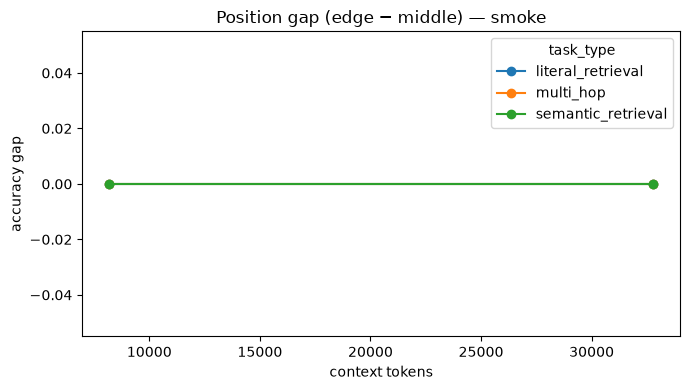

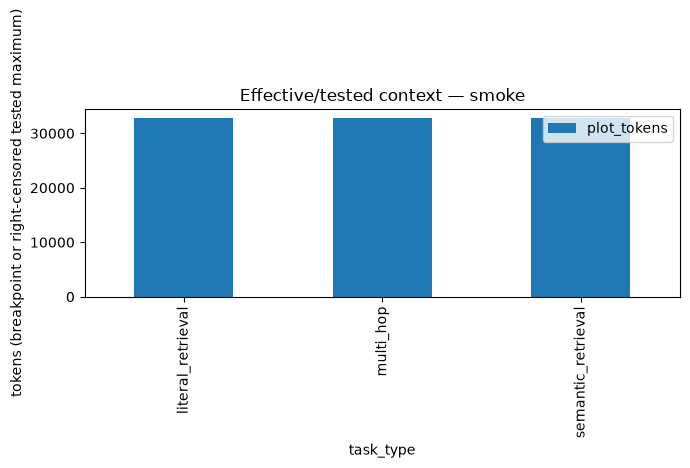

In [4]:
if analysis_ready:
    gap_rows = position_gap_rows(summary_rows)
    gap_frame = pd.DataFrame(gap_rows)
    display(gap_frame)
    gap_plot = gap_frame.pivot(index='target_context_tokens', columns='task_type', values='position_gap')
    gap_plot.plot(marker='o', figsize=(7, 4), title=f'Position gap (edge − middle) — {PHASE}')
    plt.xlabel('context tokens')
    plt.ylabel('accuracy gap')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'position-gap-vs-context.png', dpi=160)
    baseline_length = int(manifest['effective_context']['baseline_length'])
    baseline_gate = float(manifest['effective_context']['baseline_accuracy_gate'])
    alpha = float(manifest['effective_context']['alpha'])
    effective = effective_context_by_task(summary_rows, baseline_context_tokens=baseline_length, alpha=alpha, minimum_baseline_accuracy=baseline_gate)
    effective_by_position = effective_context_by_task_and_position(summary_rows, baseline_context_tokens=baseline_length, alpha=alpha, minimum_baseline_accuracy=baseline_gate)
    display(pd.DataFrame(effective)[['task_type', 'baseline_accuracy', 'status', 'crossing_context_tokens', 'effective_context_tokens', 'largest_tested_context_tokens']])
    display(pd.DataFrame(effective_by_position)[['task_type', 'evidence_position', 'baseline_accuracy', 'status', 'crossing_context_tokens', 'effective_context_tokens']])
    effective_frame = pd.DataFrame(effective)
    effective_frame['plot_tokens'] = effective_frame['effective_context_tokens'].fillna(effective_frame['largest_tested_context_tokens'])
    effective_frame.plot(x='task_type', y='plot_tokens', kind='bar', figsize=(7, 4), title=f'Effective/tested context — {PHASE}')
    plt.ylabel('tokens (breakpoint or right-censored tested maximum)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'effective-context-vs-context.png', dpi=160)
    print('Effective-context values are descriptive only when the baseline gate is satisfied; smoke values remain harness-only.')

In [5]:
if analysis_ready:
    systems = pd.DataFrame([{key: row.get(key) for key in ('task_type', 'target_context_tokens', 'median_stream_ttft_s', 'median_prefill_tokens_per_second', 'median_decode_tokens_per_second', 'median_peak_memory_bytes')} for row in available_summary_rows])
    display(systems.head(20))
    if manifest['backend'] == 'fixture':
        print('Systems values above are fixture timing values and must not be presented as model performance.')

,task_type,target_context_tokens,median_stream_ttft_s,median_prefill_tokens_per_second,median_decode_tokens_per_second,median_peak_memory_bytes
0,literal_retrieval,8192,None,4111500.0,1000.0,33980416.0
1,literal_retrieval,8192,None,4111500.0,1000.0,34193408.0
2,literal_retrieval,8192,None,4111500.0,1000.0,34357248.0
3,literal_retrieval,32768,None,16399500.0,1000.0,48087040.0
4,literal_retrieval,32768,None,16399500.0,1000.0,48906240.0
5,literal_retrieval,32768,None,16399500.0,1000.0,49004544.0
6,multi_hop,8192,None,4113500.0,1000.0,34111488.0
7,multi_hop,8192,None,4113500.0,1000.0,34275328.0
8,multi_hop,8192,None,4113500.0,1000.0,34455552.0
9,multi_hop,32768,None,16401500.0,1000.0,48103424.0


Systems values above are fixture timing values and must not be presented as model performance.
